# E0 Matched Baseline

In [19]:
import importlib
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root containing src/.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUTPUTS_ROOT = ROOT / "outputs"
print("Project root:", ROOT)
print("Outputs root:", OUTPUTS_ROOT)

import pandas as pd
from IPython.display import display

from src.config import setup_environment
from src.experiments import (
    add_latent_curve_features_to_case_df,
    run_E0_evaluation,
    run_e0_seed_sensitivity,
    run_single_case_posterior,
    summarize_empirical_coverage_with_uncertainty,
    summarize_feature_coverage_with_uncertainty,
    summarize_gamma_by_bins,
)
from src.plotting import (
    plot_e0_overall_figure,
    plot_feature_residuals,
    plot_gamma_stratified_diagnostics,
    plot_observed_curve,
    plot_parameter_coverage_with_ci,
    plot_single_case_posterior,
    plot_single_case_ppc,
    plot_training_loss,
    plot_truth_vs_median_scatter,
)
from src.workflow import train_workflow


Project root: /Users/jijiayi/Documents/25WS/GNN/GNN_Final_Project
Outputs root: /Users/jijiayi/Documents/25WS/GNN/GNN_Final_Project/outputs


In [20]:
missing = []
for pkg in ["bayesflow", "tensorflow", "keras"]:
    try:
        importlib.import_module(pkg)
        print(f"[ok] {pkg}")
    except Exception as e:
        missing.append(pkg)
        print(f"[missing] {pkg}: {e}")

if missing:
    print("\nInstall missing packages in the current kernel environment, for example:")
    print("python -m pip install bayesflow==2.0.7 tensorflow==2.17.0 keras==3.9.0 numpy==1.26.4 pandas==2.3.3 scipy==1.15.3 matplotlib==3.8.4 seaborn")
else:
    print("\nBackend check passed.")


[ok] bayesflow
[ok] tensorflow
[ok] keras

Backend check passed.


In [21]:
# Optional install cell.
# Uncomment and run this cell if the backend packages are missing,
# then restart the kernel before re-running the notebook.

import sys
print(sys.executable)
# !{sys.executable} -m pip install bayesflow==2.0.7 tensorflow==2.17.0 keras==3.9.0 numpy==1.26.4 pandas==2.3.3 scipy==1.15.3 matplotlib==3.8.4 seaborn


/opt/anaconda3/envs/bayesflow311/bin/python


In [22]:
setup_environment(seed=42)
workflow_E0, history_E0 = train_workflow(seed=42)


bayesflow: 2.0.7
tensorflow: 2.17.0
keras: 3.9.0
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.15.3
matplotlib: 3.8.4


INFO:bayesflow:Building dataset from simulator instance of LambdaSimulator.
INFO:bayesflow:Building on a test batch.


Epoch 1/12
60/60 - 81s - 1s/step - loss: 2.5321
Epoch 2/12
60/60 - 13s - 216ms/step - loss: 1.4835
Epoch 3/12
60/60 - 19s - 311ms/step - loss: 0.8538
Epoch 4/12
60/60 - 12s - 195ms/step - loss: 0.2132
Epoch 5/12
60/60 - 22s - 362ms/step - loss: 0.0919
Epoch 6/12
60/60 - 23s - 380ms/step - loss: -1.7987e-01
Epoch 7/12
60/60 - 24s - 398ms/step - loss: -4.2126e-01
Epoch 8/12
60/60 - 23s - 381ms/step - loss: -4.9899e-01
Epoch 9/12
60/60 - 19s - 324ms/step - loss: -6.9216e-01
Epoch 10/12
60/60 - 13s - 224ms/step - loss: -7.4699e-01
Epoch 11/12
60/60 - 18s - 306ms/step - loss: -8.5404e-01
Epoch 12/12
60/60 - 16s - 262ms/step - loss: -9.2118e-01


In [23]:
single_case = run_single_case_posterior(
    workflow=workflow_E0,
    true_beta=0.55,
    true_gamma=0.18,
    single_case_seed=2025,
    num_posterior_samples=4000,
    n_ppc=100,
    ppc_seed=2024,
)


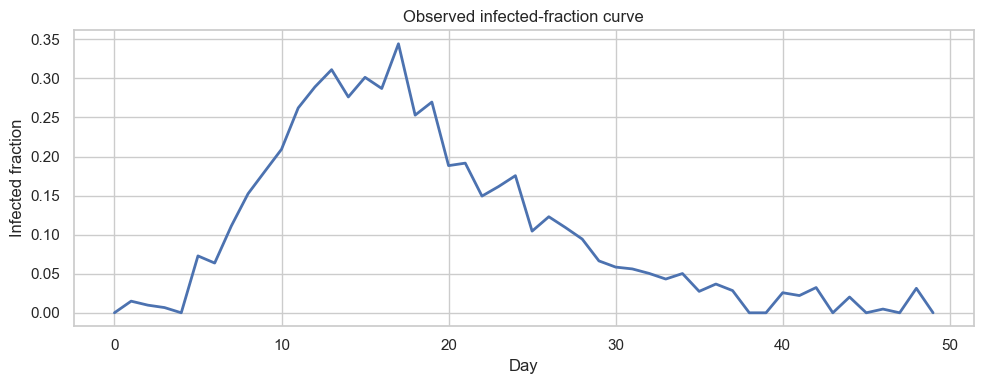

True beta: 0.55
True gamma: 0.18
True R0: 3.056


In [24]:
# Example single case
plot_observed_curve(
    single_case["observed_curve"],
    single_case["time_grid"],
    true_beta=single_case["true_beta"],
    true_gamma=single_case["true_gamma"],
    true_r0=single_case["true_r0"],
)


We first transform bounded epidemiological parameters to an unconstrained space and map posterior samples back after inference. The curve below is a single noisy SIR observation and serves as the reference example for the matched setting.

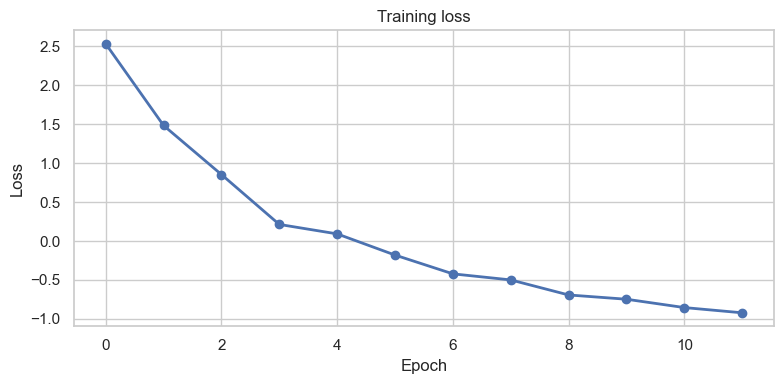

In [25]:
plot_training_loss(history_E0)


This training curve shows stable optimization in the matched SIR-to-SIR setting. The loss drops quickly and then levels off, suggesting that the amortizer learns the main mapping from noisy trajectories to posterior parameters.

In [26]:
display(single_case["summary_table"].round(4))


,mean,std,5%,50%,95%
beta,0.5454,0.0118,0.5263,0.5453,0.5653
gamma,0.1831,0.0067,0.1723,0.1830,0.1944
R0,2.9825,0.1129,2.8080,2.9765,3.1826


For this single case, posterior summaries recover `beta`, `gamma`, and `R0` well. The true values lie within the high-density posterior region, indicating good local calibration in the matched setting.

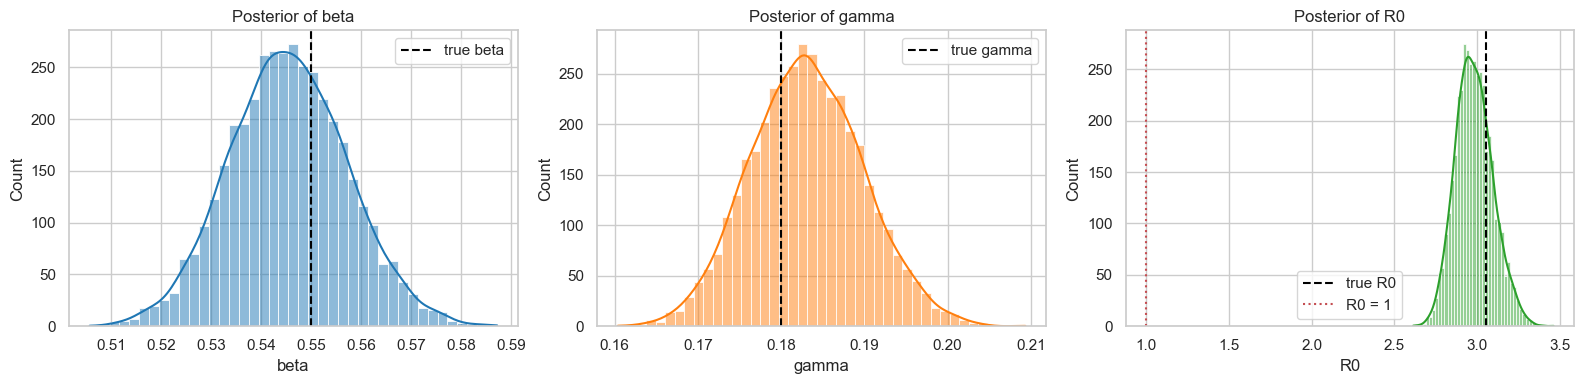

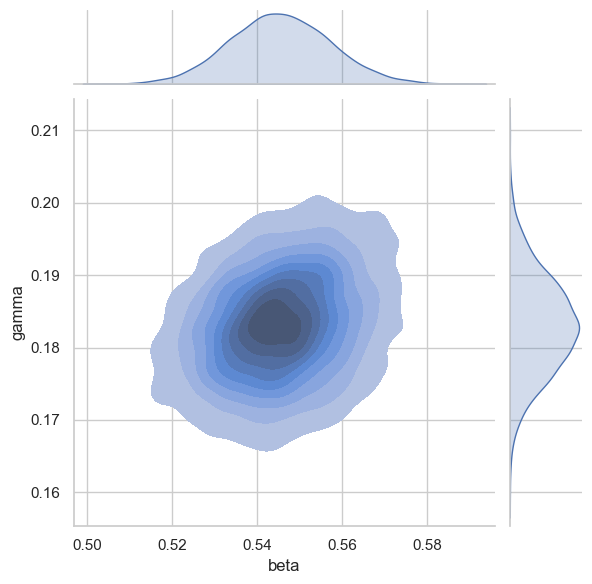

In [27]:
plot_single_case_posterior(
    single_case["posterior_df"],
    single_case["true_beta"],
    single_case["true_gamma"],
    single_case["true_r0"],
)


These posterior plots show a concentrated and well-behaved single-case posterior. The marginals are unimodal, and the joint plot suggests moderate dependence between `beta` and `gamma`.

In [28]:
print(f"True R0: {single_case['true_r0']:.3f}")
print(f"Posterior median R0: {single_case['r0_ci'][1]:.3f}")
print(f"Posterior 90% interval for R0: [{single_case['r0_ci'][0]:.3f}, {single_case['r0_ci'][2]:.3f}]")
print(f"Posterior probability R0 > 1: {single_case['prob_r0_gt_1']:.4f}")


True R0: 3.056
Posterior median R0: 2.977
Posterior 90% interval for R0: [2.808, 3.183]
Posterior probability R0 > 1: 1.0000


The derived posterior for `R0` is clearly above 1, matching the growth pattern of the observed curve. This confirms that the model recovers not only the parameters, but also the correct epidemiological regime.

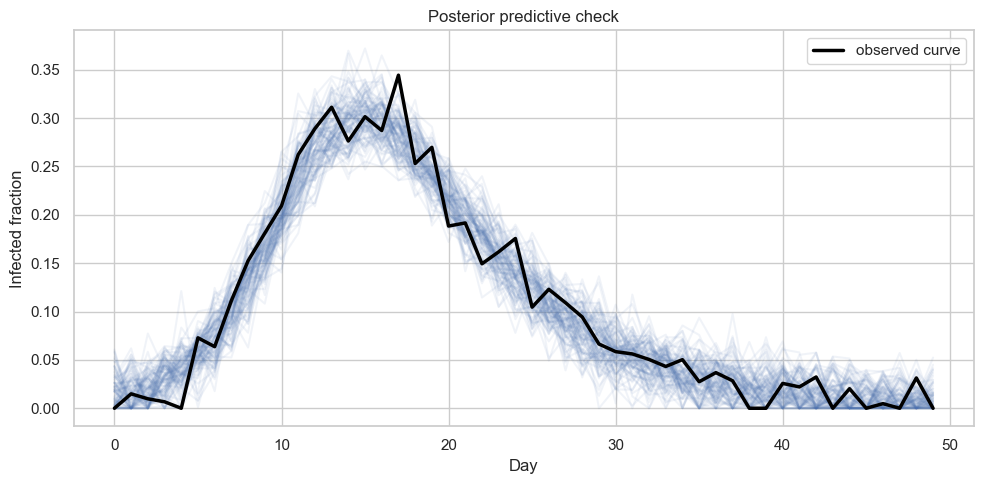

In [29]:
plot_single_case_ppc(
    single_case["ppc_curves"],
    single_case["observed_curve"],
    single_case["time_grid"],
)


This posterior predictive check shows that replicated curves reproduce the main shape of the observation. In the matched setting, predictive fit is consistent with reliable parameter inference.

In [30]:
case_df, recovery_df, coverage_df, feature_case_df, feature_summary_df = run_E0_evaluation(
    workflow=workflow_E0,
    n_test=100,
    num_posterior_samples=2000,
    n_ppc_draws=100,
    seed=2026,
)
E0_OUTPUT_DIR = OUTPUTS_ROOT / "E0"
E0_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
case_df.to_csv(E0_OUTPUT_DIR / "E0_matched_case_level.csv", index=False)
recovery_df.to_csv(E0_OUTPUT_DIR / "E0_matched_recovery_summary.csv", index=False)
coverage_df.to_csv(E0_OUTPUT_DIR / "E0_matched_coverage_summary.csv", index=False)
feature_case_df.to_csv(E0_OUTPUT_DIR / "E0_matched_ppc_feature_case_level.csv", index=False)
feature_summary_df.to_csv(E0_OUTPUT_DIR / "E0_matched_ppc_feature_summary.csv", index=False)
print("Per-case summary head:")
display(case_df.head())
print("Recovery summary:")
display(recovery_df.round(4))
print("Coverage summary:")
display(coverage_df.round(4))


Per-case summary head:


,case_id,true_beta,true_gamma,true_R0,beta_mean,beta_median,beta_std,beta_ci50_low,beta_ci50_high,beta_ci90_low,...,gamma_err_mean,gamma_err_median,gamma_abs_err_median,gamma_sq_err_median,R0_covered50,R0_covered90,R0_err_mean,R0_err_median,R0_abs_err_median,R0_sq_err_median
0,0,0.261041,0.337961,0.772401,0.186709,0.164633,0.077270,0.126207,0.227203,0.102547,...,-0.062023,-0.057712,0.057712,0.003331,1.0,1.0,0.095994,-0.008466,0.008466,0.000072
1,1,0.708075,0.309730,2.286106,0.695129,0.695741,0.024284,0.679510,0.711298,0.654069,...,0.018357,0.017669,0.017669,0.000312,0.0,0.0,-0.165776,-0.170209,0.170209,0.028971
2,2,0.404338,0.350867,1.152396,0.390357,0.389031,0.107008,0.314286,0.467448,0.218810,...,0.017063,0.030654,0.030654,0.000940,1.0,1.0,-0.065524,-0.061800,0.061800,0.003819
3,3,0.803229,0.214378,3.746785,0.798948,0.800923,0.030391,0.779200,0.820888,0.746326,...,-0.002638,-0.003025,0.003025,0.000009,1.0,1.0,0.032884,0.024465,0.024465,0.000599
4,4,0.543643,0.336812,1.614083,0.499293,0.499443,0.021896,0.484540,0.514406,0.462311,...,-0.019177,-0.019706,0.019706,0.000388,1.0,1.0,-0.039338,-0.040568,0.040568,0.001646


Recovery summary:


,quantity,bias_mean_est,bias_median_est,MAE_median_est,RMSE_median_est,corr_truth_vs_median,avg_post_std
0,beta,-0.0020,-0.0047,0.0380,0.0620,0.9702,0.0512
1,gamma,0.0015,0.0071,0.0357,0.0649,0.8711,0.0428
2,R0,-0.0164,-0.0313,0.1741,0.2543,0.9963,0.2848


Coverage summary:


,quantity,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,avg_width50,avg_width90
0,beta,0.5,0.53,0.03,0.9,0.94,0.04,0.0713,0.1652
1,gamma,0.5,0.51,0.01,0.9,0.90,0.00,0.0627,0.1377
2,R0,0.5,0.53,0.03,0.9,0.97,0.07,0.3610,0.9316


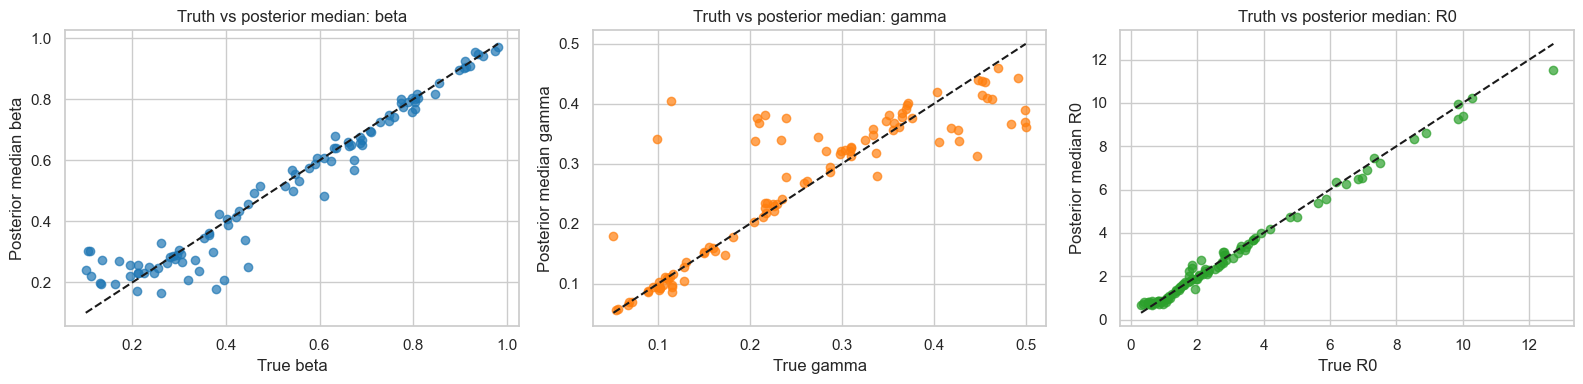

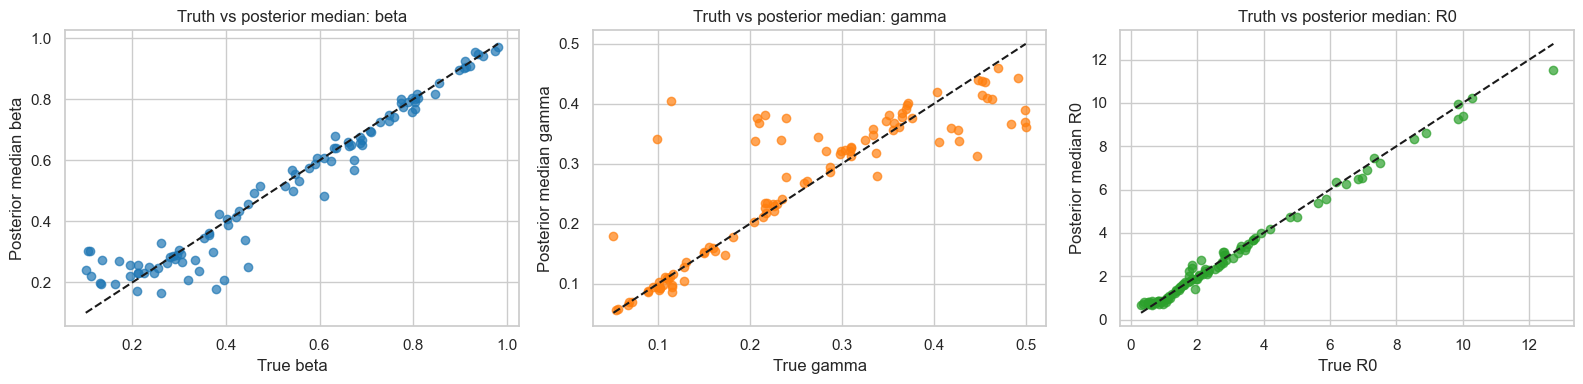

In [31]:
plot_truth_vs_median_scatter(case_df)


Across the test set, posterior medians track the true parameters closely. Recovery is strongest for `R0`, while `gamma` is somewhat harder to identify than `beta`.

In [32]:
coverage_unc_df = summarize_empirical_coverage_with_uncertainty(
    case_df=case_df,
    quantities=("beta", "gamma", "R0"),
    alpha=0.05,
)
coverage_unc_df.to_csv(E0_OUTPUT_DIR / "E0_matched_coverage_summary_with_uncertainty.csv", index=False)
display(coverage_unc_df.round(4))


,quantity,n_cases,nominal_50,k_50,empirical_50,diff_50,ci95_50_low,ci95_50_high,nominal_90,k_90,empirical_90,diff_90,ci95_90_low,ci95_90_high
0,beta,100,0.5,53,0.53,0.03,0.4329,0.6249,0.9,94,0.94,0.04,0.8752,0.9722
1,gamma,100,0.5,51,0.51,0.01,0.4135,0.6058,0.9,90,0.90,0.00,0.8256,0.9448
2,R0,100,0.5,53,0.53,0.03,0.4329,0.6249,0.9,97,0.97,0.07,0.9155,0.9897


In [35]:
import importlib
import src.plotting as plotting
importlib.reload(plotting)

from src.plotting import plot_parameter_coverage_with_ci


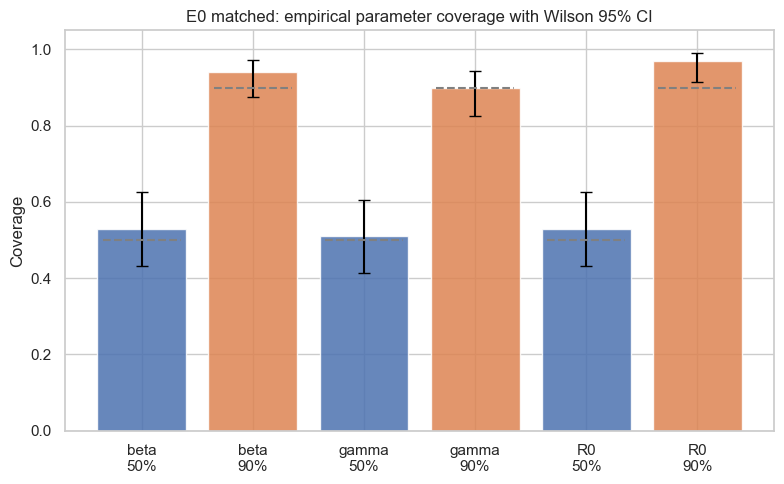

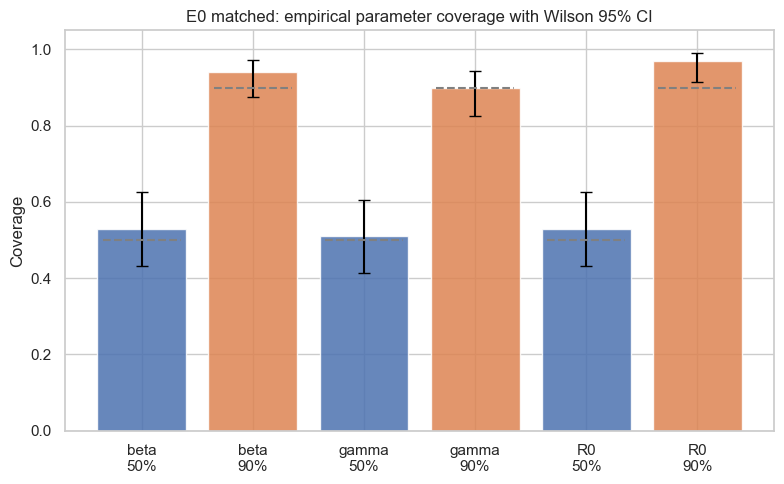

In [36]:
plot_parameter_coverage_with_ci(
    coverage_unc_df,
    out_path=str(E0_OUTPUT_DIR / "E0_matched_parameter_coverage_with_CI.png"),
)


In [37]:
seed_sensitivity_df = run_e0_seed_sensitivity(
    train_seeds=(11, 22, 42),
    eval_seed=2026,
    n_test=100,
    num_posterior_samples=2000,
)
seed_sensitivity_df.to_csv(E0_OUTPUT_DIR / "E0_seed_sensitivity.csv", index=False)
display(seed_sensitivity_df.round(4))


INFO:bayesflow:Building dataset from simulator instance of LambdaSimulator.
INFO:bayesflow:Building on a test batch.


Epoch 1/12
60/60 - 83s - 1s/step - loss: 2.5995
Epoch 2/12
60/60 - 13s - 211ms/step - loss: 1.5741
Epoch 3/12
60/60 - 18s - 307ms/step - loss: 0.9059
Epoch 4/12
60/60 - 13s - 222ms/step - loss: 0.1799
Epoch 5/12
60/60 - 14s - 226ms/step - loss: -9.8776e-02
Epoch 6/12
60/60 - 15s - 256ms/step - loss: -3.5173e-01
Epoch 7/12
60/60 - 14s - 235ms/step - loss: -4.4088e-01
Epoch 8/12
60/60 - 19s - 321ms/step - loss: -3.9862e-01
Epoch 9/12
60/60 - 13s - 217ms/step - loss: -5.8641e-01
Epoch 10/12
60/60 - 15s - 247ms/step - loss: -9.0168e-01
Epoch 11/12
60/60 - 15s - 247ms/step - loss: -8.4806e-01
Epoch 12/12
60/60 - 13s - 209ms/step - loss: -9.7577e-01


INFO:bayesflow:Building dataset from simulator instance of LambdaSimulator.
INFO:bayesflow:Building on a test batch.


Epoch 1/12
60/60 - 81s - 1s/step - loss: 2.4595
Epoch 2/12
60/60 - 13s - 211ms/step - loss: 1.5299
Epoch 3/12
60/60 - 12s - 201ms/step - loss: 0.9190
Epoch 4/12
60/60 - 17s - 283ms/step - loss: 0.1130
Epoch 5/12
60/60 - 13s - 220ms/step - loss: -6.5302e-02
Epoch 6/12
60/60 - 12s - 202ms/step - loss: -3.0892e-01
Epoch 7/12
60/60 - 20s - 341ms/step - loss: -5.2957e-01
Epoch 8/12
60/60 - 17s - 281ms/step - loss: -6.2650e-01
Epoch 9/12
60/60 - 18s - 296ms/step - loss: -3.9274e-01
Epoch 10/12
60/60 - 21s - 346ms/step - loss: -7.3571e-01
Epoch 11/12
60/60 - 12s - 204ms/step - loss: -7.6459e-01
Epoch 12/12
60/60 - 12s - 194ms/step - loss: -9.1642e-01


INFO:bayesflow:Building dataset from simulator instance of LambdaSimulator.
INFO:bayesflow:Building on a test batch.


Epoch 1/12
60/60 - 111s - 2s/step - loss: 2.5489
Epoch 2/12
60/60 - 24s - 402ms/step - loss: 1.5069
Epoch 3/12
60/60 - 12s - 205ms/step - loss: 0.8921
Epoch 4/12
60/60 - 11s - 191ms/step - loss: 0.2721
Epoch 5/12
60/60 - 18s - 293ms/step - loss: 0.1515
Epoch 6/12
60/60 - 12s - 196ms/step - loss: -2.8976e-01
Epoch 7/12
60/60 - 12s - 207ms/step - loss: -4.6728e-01
Epoch 8/12
60/60 - 16s - 272ms/step - loss: -4.7492e-01
Epoch 9/12
60/60 - 11s - 182ms/step - loss: -7.9039e-01
Epoch 10/12
60/60 - 13s - 217ms/step - loss: -7.6117e-01
Epoch 11/12
60/60 - 12s - 194ms/step - loss: -9.1712e-01
Epoch 12/12
60/60 - 15s - 245ms/step - loss: -8.7788e-01


,train_seed,beta_corr,gamma_corr,R0_corr,beta_emp90,gamma_emp90,R0_emp90
0,11,0.9703,0.8657,0.9983,0.91,0.89,0.94
1,22,0.9719,0.8678,0.9978,0.91,0.92,0.94
2,42,0.9699,0.8721,0.9962,0.94,0.92,0.97


In [38]:
case_df_with_latent = add_latent_curve_features_to_case_df(case_df)
print(case_df_with_latent[["case_id", "true_beta", "true_gamma", "true_R0", "latent_peak_height", "latent_peak_time"]].head().round(4))


   case_id  true_beta  true_gamma  true_R0  latent_peak_height  \
0        0     0.2610      0.3380   0.7724              0.0100   
1        1     0.7081      0.3097   2.2861              0.2052   
2        2     0.4043      0.3509   1.1524              0.0179   
3        3     0.8032      0.2144   3.7468              0.3821   
4        4     0.5436      0.3368   1.6141              0.0899   

   latent_peak_time  
0               0.0  
1              12.0  
2              22.0  
3              10.0  
4              17.0  


In [39]:
gamma_strat_truegamma_df, case_df_gamma_binned = summarize_gamma_by_bins(
    case_df=case_df,
    bin_col="true_gamma",
    n_bins=4,
    binning="quantile",
    alpha=0.05,
)
gamma_strat_truegamma_df.to_csv(E0_OUTPUT_DIR / "E0_gamma_stratified_by_true_gamma.csv", index=False)
display(gamma_strat_truegamma_df.round(4))


,bin,n_cases,gamma_MAE_median_est,gamma_bias_median_est,gamma_empirical_90,gamma_ci95_90_low,gamma_ci95_90_high
0,"(0.050499999999999996, 0.125]",25,0.0318,0.0218,0.84,0.6535,0.9360
1,"(0.125, 0.234]",25,0.0349,0.0292,0.92,0.7503,0.9778
2,"(0.234, 0.358]",25,0.0250,0.0187,1.00,0.8668,1.0000
3,"(0.358, 0.5]",25,0.0512,-0.0412,0.84,0.6535,0.9360


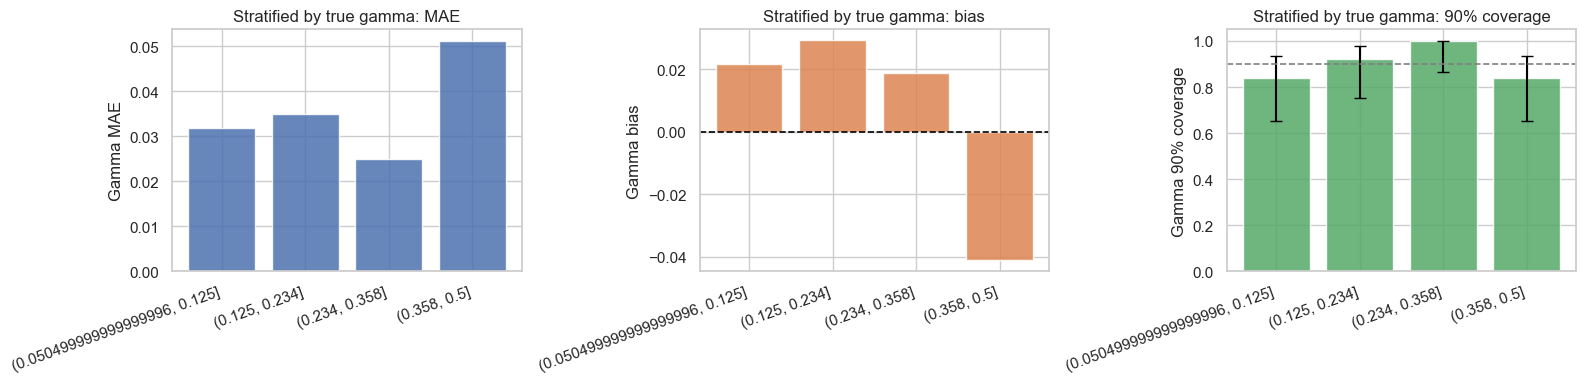

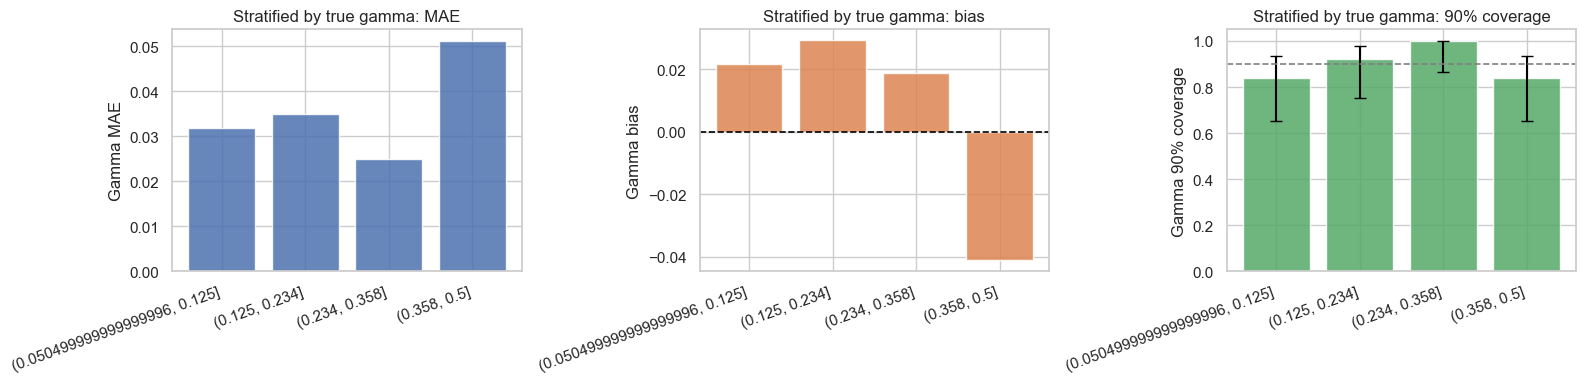

In [40]:
plot_gamma_stratified_diagnostics(
    gamma_strat_truegamma_df,
    title_prefix="Stratified by true gamma",
    out_path=str(E0_OUTPUT_DIR / "E0_gamma_diagnostics_by_true_gamma.png"),
)


In [41]:
gamma_strat_peak_df, case_df_peak_binned = summarize_gamma_by_bins(
    case_df=case_df_with_latent,
    bin_col="latent_peak_height",
    n_bins=4,
    binning="quantile",
    alpha=0.05,
)
gamma_strat_peak_df.to_csv(E0_OUTPUT_DIR / "E0_gamma_stratified_by_latent_peak_height.csv", index=False)
display(gamma_strat_peak_df.round(4))


,bin,n_cases,gamma_MAE_median_est,gamma_bias_median_est,gamma_empirical_90,gamma_ci95_90_low,gamma_ci95_90_high
0,"(0.009000000000000001, 0.017]",25,0.1030,0.0221,0.76,0.5657,0.8850
1,"(0.017, 0.153]",25,0.0259,0.0013,0.96,0.8046,0.9929
2,"(0.153, 0.352]",25,0.0113,0.0049,0.88,0.7004,0.9583
3,"(0.352, 0.721]",25,0.0027,0.0002,1.00,0.8668,1.0000


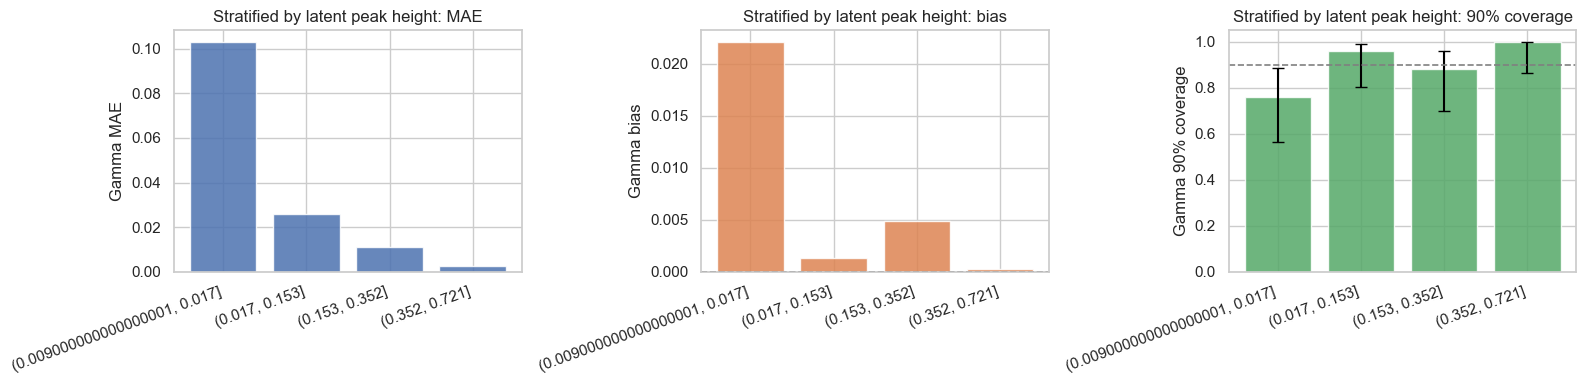

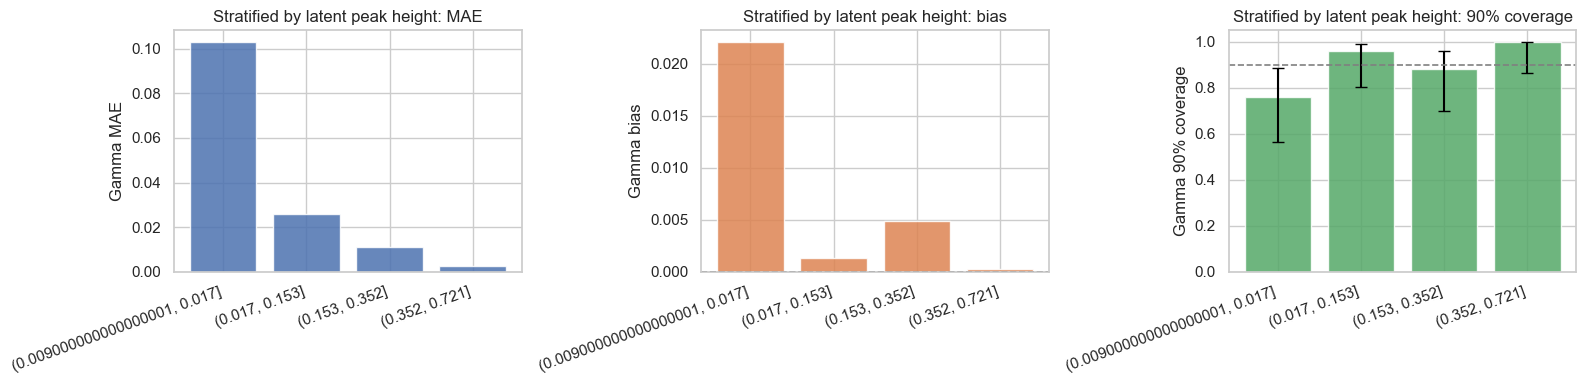

In [42]:
plot_gamma_stratified_diagnostics(
    gamma_strat_peak_df,
    title_prefix="Stratified by latent peak height",
    out_path=str(E0_OUTPUT_DIR / "E0_gamma_diagnostics_by_latent_peak_height.png"),
)


In [43]:
display(feature_summary_df.round(4))
display(feature_case_df.head().round(4))


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.65,0.15,0.9,0.92,0.02,0.8513,0.4650,6.7750,10.3609,7.3252,11.8200,22.5265
1,peak_height,0.5,0.59,0.09,0.9,0.95,0.05,-0.0013,-0.0040,0.0132,0.0176,0.0240,0.0254,0.0725
2,cumulative_infected,0.5,0.74,0.24,0.9,1.00,0.10,0.1064,0.0231,0.1894,0.3309,0.5318,0.5048,1.5417
3,early_growth_slope,0.5,0.58,0.08,0.9,0.92,0.02,-0.0012,-0.0011,0.0023,0.0030,0.0036,0.0046,0.0113


,case_id,feature,observed_value,pred_mean,pred_median,pred_std,pred_ci50_low,pred_ci50_high,pred_ci90_low,pred_ci90_high,...,pred_width90,covered50,covered90,err_mean,err_median,abs_err_median,sq_err_median,true_beta,true_gamma,true_R0
0,0,peak_time,47.0000,27.3300,27.0000,15.5836,13.0000,42.2500,2.0000,49.0000,...,47.0000,0.0,1.0,-19.6700,-20.0000,20.0000,400.0000,0.2610,0.3380,0.7724
1,0,peak_height,0.0632,0.0649,0.0510,0.0371,0.0431,0.0666,0.0346,0.1387,...,0.1042,1.0,1.0,0.0017,-0.0122,0.0122,0.0001,0.2610,0.3380,0.7724
2,0,cumulative_infected,0.6088,0.9192,0.4960,0.9386,0.3976,1.0302,0.3172,2.7896,...,2.4724,1.0,1.0,0.3104,-0.1128,0.1128,0.0127,0.2610,0.3380,0.7724
3,0,early_growth_slope,-0.0024,-0.0005,-0.0004,0.0023,-0.0020,0.0011,-0.0041,0.0030,...,0.0071,0.0,1.0,0.0019,0.0020,0.0020,0.0000,0.2610,0.3380,0.7724
4,1,peak_time,26.0000,26.9700,28.0000,14.4043,14.7500,39.2500,3.0000,47.0500,...,44.0500,1.0,1.0,0.9700,2.0000,2.0000,4.0000,0.2339,0.1921,1.2174


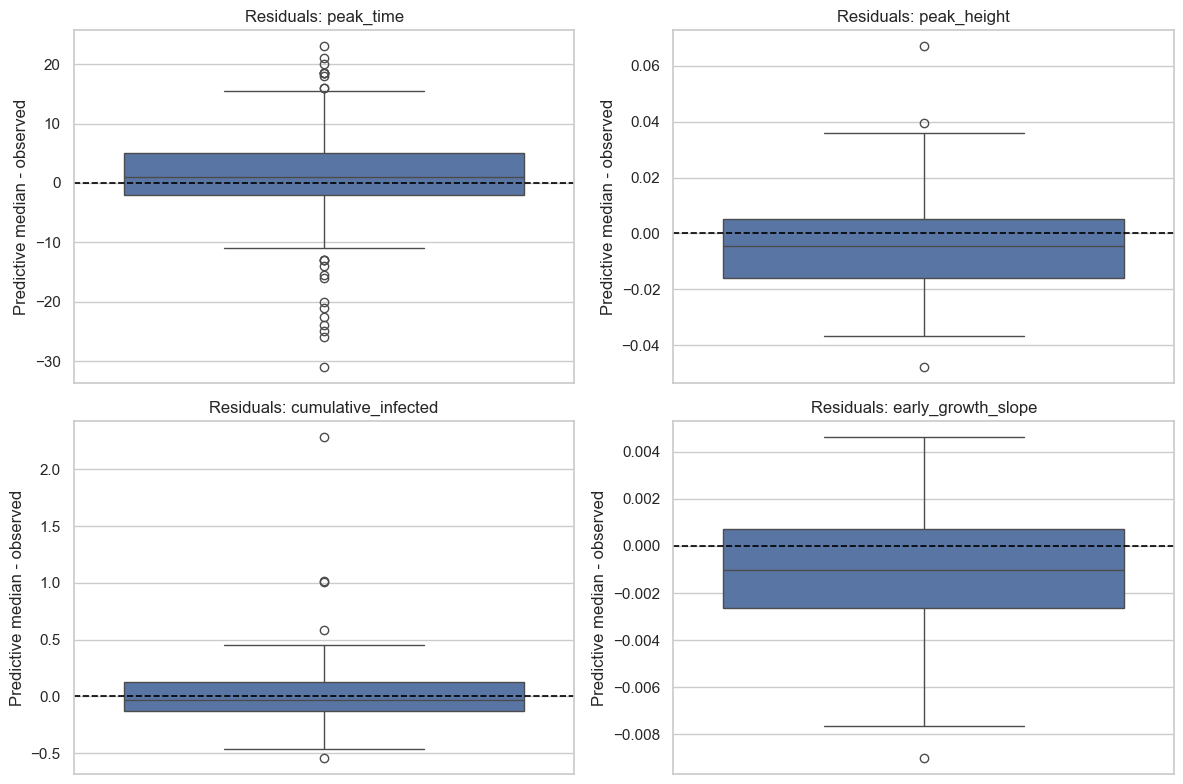

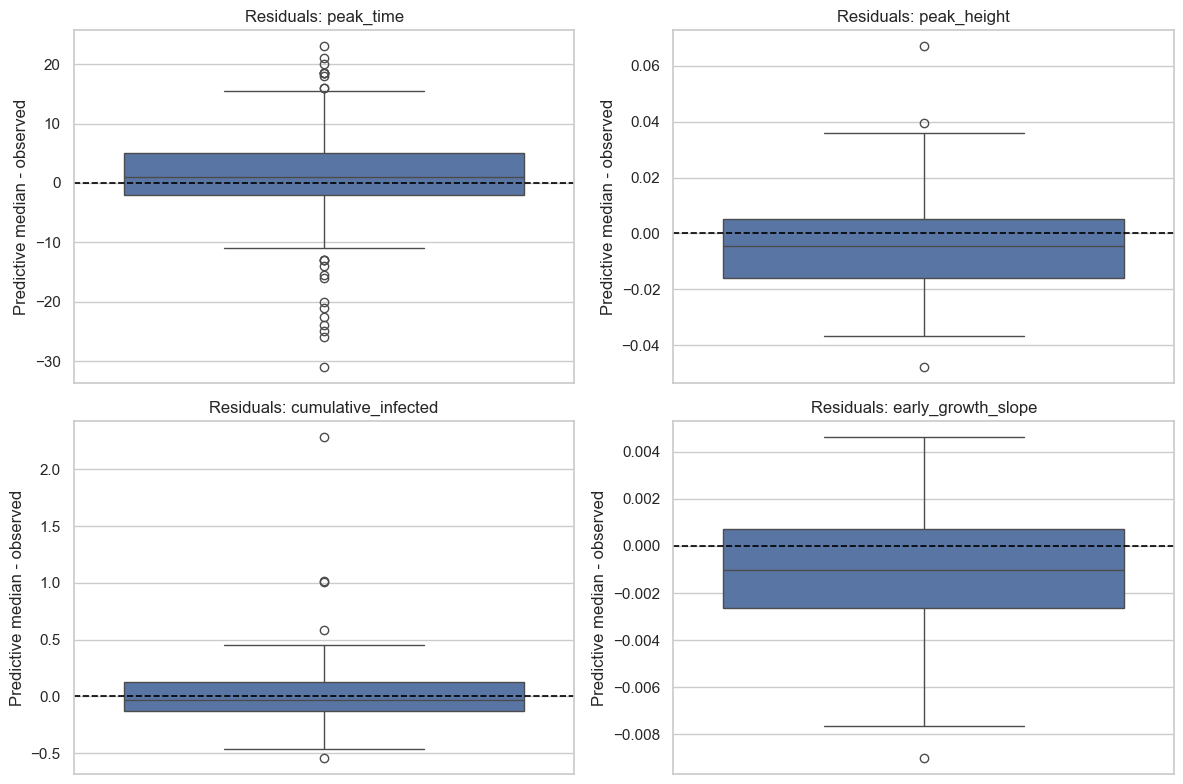

In [44]:
plot_feature_residuals(feature_case_df)


In [45]:
feature_cov_unc_df = summarize_feature_coverage_with_uncertainty(
    feature_case_df,
    alpha=0.05,
)
feature_cov_unc_df.to_csv(E0_OUTPUT_DIR / "E0_matched_ppc_feature_coverage_with_uncertainty.csv", index=False)
display(feature_cov_unc_df.round(4))


,feature,n_cases,nominal_50,k_50,empirical_50,diff_50,ci95_50_low,ci95_50_high,nominal_90,k_90,empirical_90,diff_90,ci95_90_low,ci95_90_high,avg_pred_width50,avg_pred_width90
0,cumulative_infected,100,0.5,74,0.74,0.24,0.6463,0.8160,0.9,100,1.00,0.10,0.9630,1.0000,0.5048,1.5417
1,early_growth_slope,100,0.5,58,0.58,0.08,0.4821,0.6720,0.9,92,0.92,0.02,0.8500,0.9589,0.0046,0.0113
2,peak_height,100,0.5,59,0.59,0.09,0.4920,0.6813,0.9,95,0.95,0.05,0.8882,0.9785,0.0254,0.0725
3,peak_time,100,0.5,65,0.65,0.15,0.5525,0.7364,0.9,92,0.92,0.02,0.8500,0.9589,11.8200,22.5265


Feature-level PPC provides a second matched-setting check. Coverage is generally close to nominal, indicating that the predictive distribution captures the main summary features of the observed curves.

## Overall E0 Baseline Figure

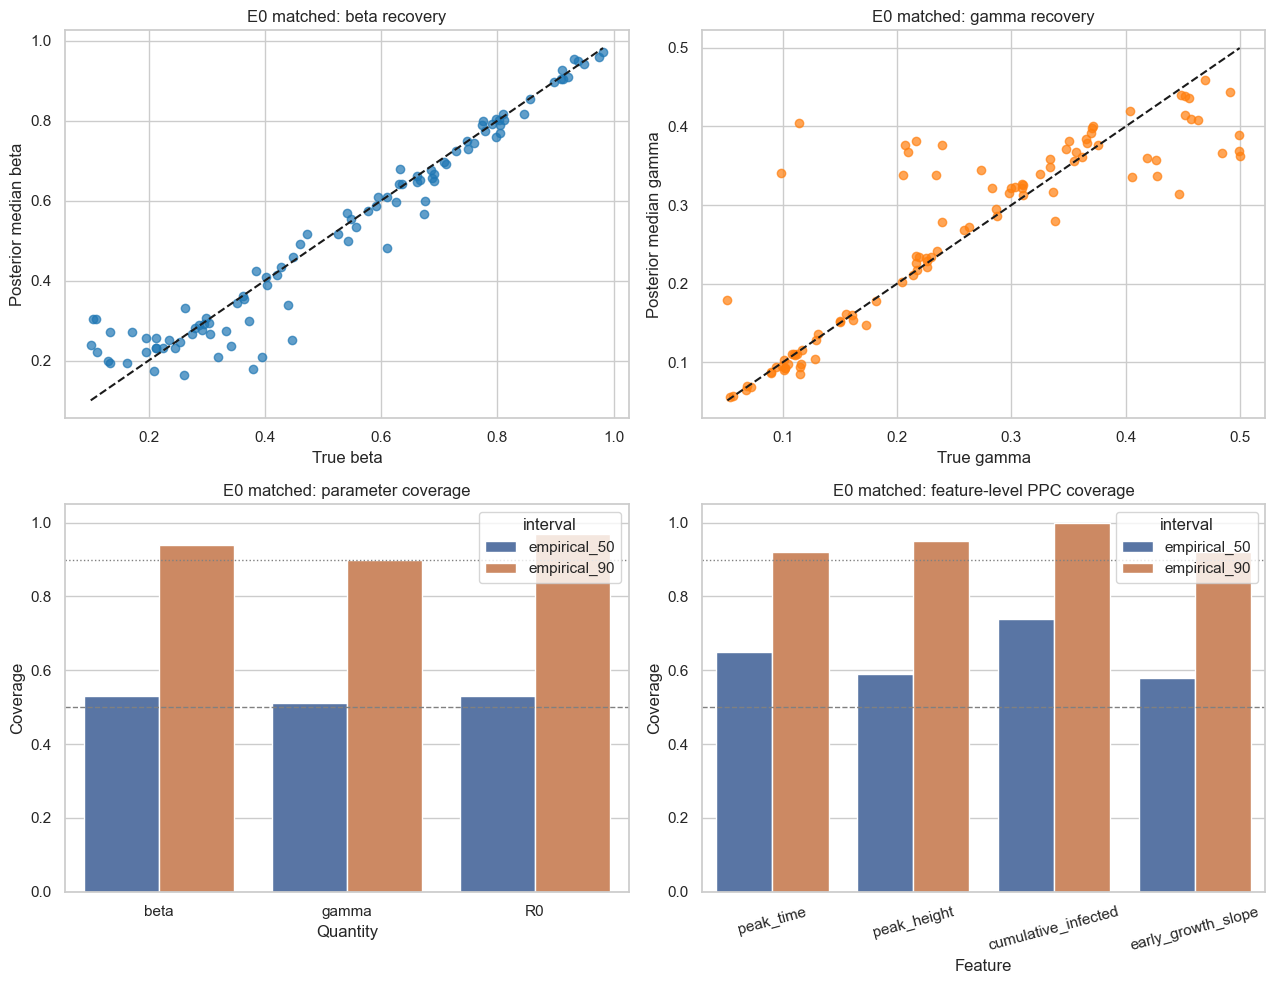

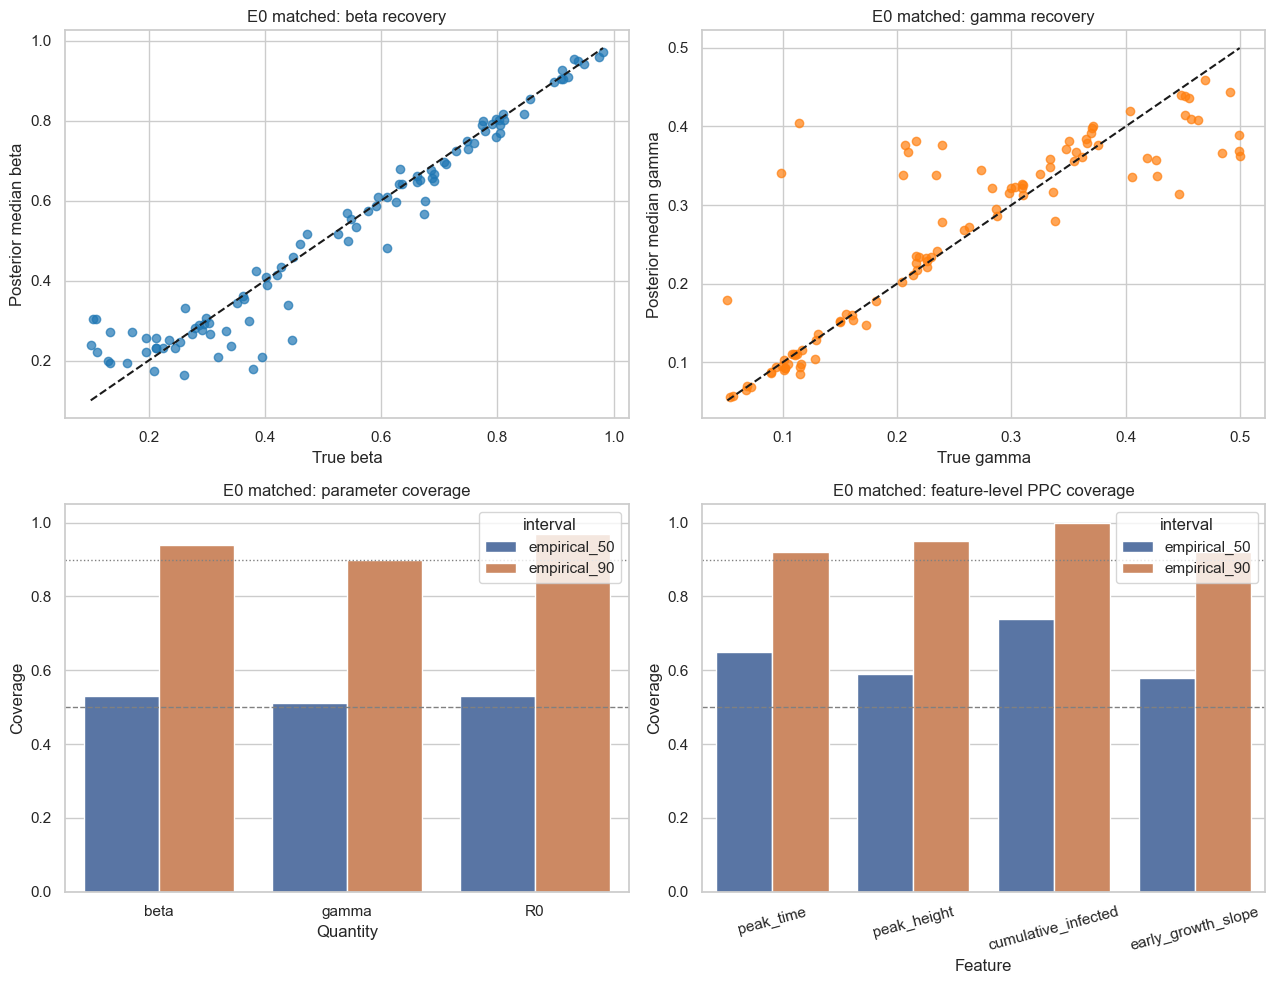

In [46]:
plot_e0_overall_figure(
    case_df,
    coverage_df,
    feature_summary_df,
    out_path=str(E0_OUTPUT_DIR / "E0_matched_overall_baseline_figure.png"),
)


This figure summarizes the matched baseline. Recovery is strong, parameter coverage is broadly well calibrated, and feature-level PPC remains close to nominal. E0 therefore serves as the reference point for the misspecification experiments.